Quick trend fitting analysis to compare effect of ENSO on monthly temperatures vs effect of AGW on monthly temperatures

- aggregate to 2x2 degree grid cells globally (extract land surface first)
- compare linear Nino vs broken stick approach (separate Nino & Nina conditions)
- effect of concurrent ENSO conditions vs antecedent ENSO conditions?

Replicate ECMWF analysis in a linear modelling framework so we can compare the effect strength directly:  
https://confluence.ecmwf.int/display/COPSRV/ENSO+impacts+on+Europe

# Pre-process data

In [97]:
# ! wget https://climexp.knmi.nl/data/era5_t2m_0-360E_-90-90N_-999-lastyear_su.nc
# ! wget https://climexp.knmi.nl/data/lsmask_era5_t2m_0-360E_-90-90N_-999-lastyear_su.nc
# ! wget https://climexp.knmi.nl/data/iersst_nino3.4a_rel.nc
# ! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.nc

--2025-07-07 11:50:42--  https://climexp.knmi.nl/data/iersst_nino3.4a_rel.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43032 (42K) [application/x-netcdf]
Saving to: ‘iersst_nino3.4a_rel.nc’

iersst_nino3.4a_rel 100%[===================>]  42.02K  --.-KB/s    in 0.02s   

2025-07-07 11:50:43 (2.50 MB/s) - ‘iersst_nino3.4a_rel.nc’ saved [43032/43032]



In [168]:
import sys; sys.path.append('../../../wwa'); from wwa import *

mapproj = cartopy.crs.PlateCarree()

subplot_kws = {"projection" : mapproj}
cbar_kwargs = {"location" : "bottom", "pad" : 0.035, "fraction" : 0.05, "shrink" : 0.85}

In [57]:
lsm = wrap_lon(xr.open_dataset("lsmask_era5_t2m_0-360E_-90-90N_-999-lastyear_su.nc").lsm.squeeze(drop = True))

da = wrap_lon(decode_times(xr.open_dataset("era5_t2m_0-360E_-90-90N_-999-lastyear_su.nc", decode_times = False)).t2m)
da = da.where(lsm >= 0.5)

da.to_netcdf("t2m-monthly_era5_0.25deg-land.nc")

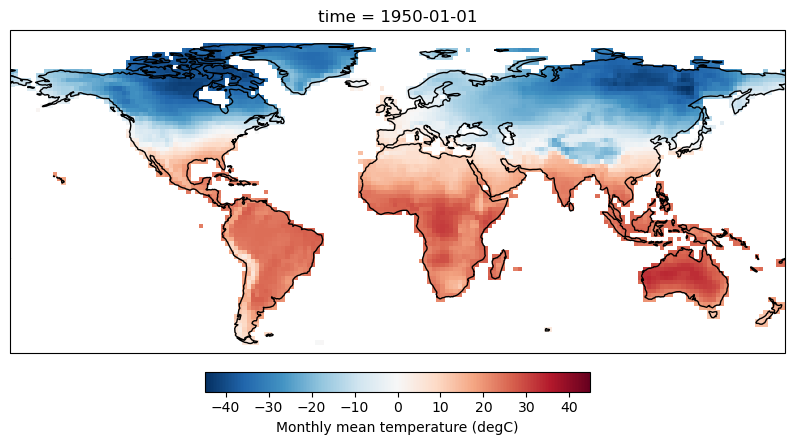

In [120]:
fig = da.isel(time = 0).plot(figsize = (10,5), subplot_kws = subplot_kws, cbar_kwargs = cbar_kwargs | {"label" : "Monthly mean temperature (degC)"})
ax = plt.gca()
ax.coastlines()

In [83]:
da_2deg = da.sel(lat = slice(-60,None)).coarsen(lon = 8, lat = 8, boundary = "trim").mean()
da_2deg.to_netcdf("t2m-monthly_era5_2deg-land.nc")

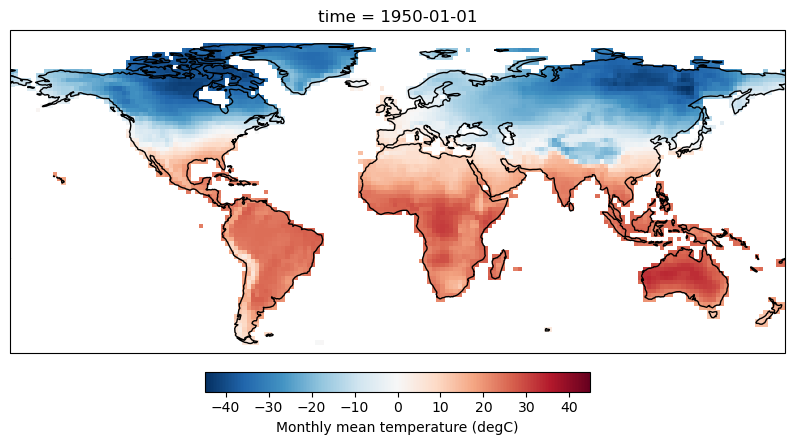

In [121]:
da_2deg.isel(time = 0).plot(figsize = (10,5), subplot_kws = subplot_kws, cbar_kwargs = cbar_kwargs | {"label" : "Monthly mean temperature (degC)"})
ax = plt.gca()
ax.coastlines()

## List of ENSO states

In [192]:
df = pd.read_csv("ecmwf-enso-states.csv", index_col = 0)
df[np.isnan(df)] = 0

df = df.stack().reset_index()
df.index = [datetime(v.year, int(v.level_1), 1) for k,v in df.iterrows()]

In [350]:
nino = decode_times(xr.open_dataset("iersst_nino3.4a_rel.nc", decode_times = False))["Nino3.4r"].resample(time = "MS").mean().rolling(time = 3).mean()
nino = nino.sel(time = slice("1950","2024"))

nino_det = pd.read_csv("../detrended_nino34/nino34_detrended.csv", index_col = "time", parse_dates = ["time"]).loc[slice("1950","2024")].to_xarray().nino34.rolling(time = 3).mean()

In [351]:
qq_nino = nino.dropna("time", "any").groupby("time.month").quantile(0.75)
qq_nina = nino.dropna("time", "any").groupby("time.month").quantile(0.25)

qqdet_nino = nino_det.dropna("time", "any").groupby("time.month").quantile(0.75)
qqdet_nina = nino_det.dropna("time", "any").groupby("time.month").quantile(0.25)

In [352]:
# which is the better classifier?
nino_class = xr.zeros_like(nino) + xr.ones_like(nino).where(nino.groupby("time.month") > qq_nino,0) - xr.ones_like(nino).where(nino.groupby("time.month") < qq_nina,0)
ninodet_class = xr.zeros_like(nino_det) + xr.ones_like(nino_det).where(nino_det.groupby("time.month") > qqdet_nino,0) - xr.ones_like(nino_det).where(nino_det.groupby("time.month") < qqdet_nina,0)

In [353]:
compare = merge_byindex([df[[0]], nino_class.to_dataframe()[["Nino3.4r"]], ninodet_class.to_dataframe()[["nino34"]]]).rename(columns = {0 : "ecmwf", "Nino3.4r" : "rel", "nino34" : "det"})

In [354]:
# doesn't make much difference if we use relative or detrended in this setting (I guess because quantiles are also per calendar month)
# differences are slightly larger if we take 3-month smooth just because of reweighting of neighbouring months
pd.crosstab(compare.rel, compare.det)

det,-1.0,0.0,1.0
rel,,,
-1.0,224,4,0
0.0,4,438,2
1.0,0,2,226


In [355]:
pd.crosstab(compare.ecmwf, compare.rel)

# using individual months
#       rel 	-1.0 	0.0 	1.0
# ecmwf -1.0 	129 	26 	    0
#        0.0 	73      242 	35
#        1.0 	0 	    35 	    120


# using 3-month rolling mean                    ## SLIGHTLY BETTER ON MATCHING NEUTRAL STATES IN ECMWF
#       rel 	-1.0 	0.0 	1.0
# ecmwf -1.0 	132 	23 	    0
#        0.0 	70 	    248 	32
#        1.0 	0 	    34 	    121

rel,-1.0,0.0,1.0
ecmwf,,,
-1.0,132,23,0
0.0,70,248,32
1.0,0,34,121


In [356]:
pd.crosstab(compare.ecmwf, compare.det)

# using individual months
#       det 	-1.0 	0.0 	1.0
# ecmwf -1.0 	128 	27    	0
#        0.0 	74 	    241 	35
#        1.0 	0 	    35 	    120

# using 3-month rolling mean
#       det 	-1.0 	0.0 	1.0
# ecmwf -1.0 	132 	23 	    0
#        0.0 	72 	    245 	33
#       1.0 	0 	    34 	    121

det,-1.0,0.0,1.0
ecmwf,,,
-1.0,132,23,0
0.0,72,245,33
1.0,0,34,121


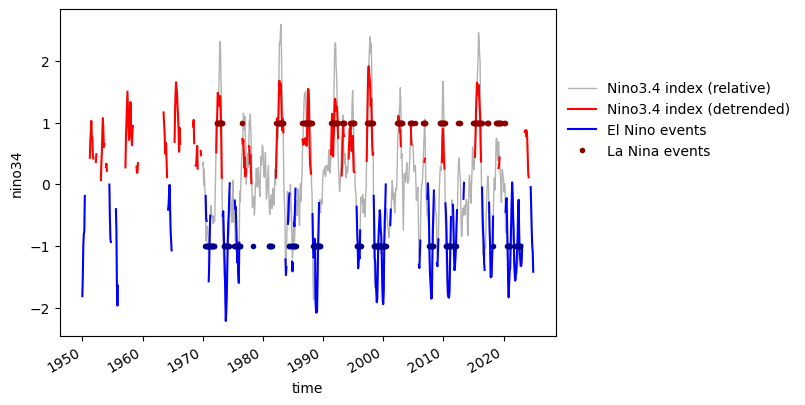

In [349]:
# overlay ECMWF ENSO states on relative Nino3.4 index
nino.sel(time = slice("1970","2022")).plot(color = "k", lw = 1, alpha = 0.3)
ax = plt.gca()

# nino.where(nino.groupby("time.month") > qq_nino).plot(color = "red")
# nino.where(nino.groupby("time.month") < qq_nina).plot(color = "blue")

# nino_det.plot(ax = ax, color = "k", lw = 1, legend = None)
nino_det.where(nino_det.groupby("time.month") > qqdet_nino).plot(color = "red")
nino_det.where(nino_det.groupby("time.month") < qqdet_nina).plot(color = "blue")


df.loc[df[0] == 1, [0]].plot(ls = "", marker = ".", ax = ax, color = "darkred", label = "El Nino events", legend = None)
df.loc[df[0] == -1, [0]].plot(ls = "", marker = ".", ax = ax, color = "darkblue", label = "La Nina events", legend = None)

# (xr.zeros_like(nino).groupby("time.month") + qq_nino).plot(ax = ax)
# (xr.zeros_like(nino).groupby("time.month") + qq_nina).plot(ax = ax)

plt.gcf().legend(["Nino3.4 index (relative)", "Nino3.4 index (detrended)", "El Nino events", "La Nina events"],
                 bbox_to_anchor = [0.9,0.65], loc = "center left", edgecolor = "w")

# Quick (separate) linear fits

In [178]:
da = xr.open_dataset("t2m-monthly_era5_2deg-land.nc").t2m.sel(time = slice(None, "2024")) # Nino3.4 not yet available
gmst = pd.read_table("gmst.txt", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")
nino = decode_times(xr.open_dataset("iersst_nino3.4a_rel.nc", decode_times = False))["Nino3.4r"].resample(time = "MS").mean() # resample to first of month

In [ ]:
for m in range(1,13):
    
    fig, axs = plt.subplots(ncols = 2, figsize = (12,3), subplot_kw = subplot_kws, dpi = 100)
    plt.subplots_adjust(wspace = 0.05)
    
    da_m = da.groupby("time.month")[m]
    
    plot_kwargs = {"cmap" : "RdBu_r", "vmin" : -4, "vmax" : 4}
    
    gmst_coeffs = da_m.assign_coords(time = gmst.loc[da_m.time.dt.year, "gmst"].values).polyfit("time", deg = 1).polyfit_coefficients
    nino_coeffs = da_m.assign_coords(time = nino.sel(time = da_m.time).values).polyfit("time", deg = 1).polyfit_coefficients
    
    gmst_coeffs.sel(degree = 1).plot(ax = axs[0], **plot_kwargs, cbar_kwargs = cbar_kwargs | {"label" : "Change per degree GMST"})
    nino_coeffs.sel(degree = 1).plot(ax = axs[1], **plot_kwargs, cbar_kwargs = cbar_kwargs | {"label" : "Change per degree Nino3.4rel"})
    
    axs[0].set_title("Global warming")
    axs[1].set_title("Concurrent ENSO state")
    
    for ax in axs: 
        ax.coastlines()

    plt.suptitle("Effect of ENSO and global warming on temperatures in "+datetime(2025,m,1).strftime("%B"), fontweight = "bold")
    plt.savefig("fig/relative-coeffs_pythonfit_"+str(m).rjust(2,"0")); plt.close()

# Quick (separate) fits - broken stick (Nino/Nina split out)

In [181]:
da = xr.open_dataset("t2m-monthly_era5_2deg-land.nc").t2m.sel(time = slice(None, "2024")) # Nino3.4 not yet available
gmst = pd.read_table("gmst.txt", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")
enso = decode_times(xr.open_dataset("iersst_nino3.4a_rel.nc", decode_times = False))["Nino3.4r"].resample(time = "MS").mean() # resample to first of month
nino = enso.where(enso > 0, 0)
nina = enso.where(enso < 0, 0)

In [184]:
for m in range(1,13):
    
    fig, axs = plt.subplots(ncols = 3, figsize = (18,3), subplot_kw = subplot_kws, dpi = 100)
    plt.subplots_adjust(wspace = 0.05)
    
    da_m = da.groupby("time.month")[m]
    
    plot_kwargs = {"cmap" : "RdBu_r", "vmin" : -4, "vmax" : 4}
    
    gmst_coeffs = da_m.assign_coords(time = gmst.loc[da_m.time.dt.year, "gmst"].values).polyfit("time", deg = 1).polyfit_coefficients
    nino_coeffs = da_m.assign_coords(time = nino.sel(time = da_m.time).values).polyfit("time", deg = 1).polyfit_coefficients
    nina_coeffs = da_m.assign_coords(time = nina.sel(time = da_m.time).values).polyfit("time", deg = 1).polyfit_coefficients
    
    gmst_coeffs.sel(degree = 1).plot(ax = axs[0], **plot_kwargs, cbar_kwargs = cbar_kwargs | {"label" : "Change per degree GMST"})
    nino_coeffs.sel(degree = 1).plot(ax = axs[1], **plot_kwargs, cbar_kwargs = cbar_kwargs | {"label" : "Change per degree Nino"})
    nina_coeffs.sel(degree = 1).plot(ax = axs[2], **plot_kwargs, cbar_kwargs = cbar_kwargs | {"label" : "Change per degree Nina"})

    axs[0].set_title("Global warming")
    axs[1].set_title("Concurrent ENSO state is El Nino")
    axs[2].set_title("Concurrent ENSO state is La Nina")
    
    for ax in axs: 
        ax.coastlines()

    plt.suptitle("Effect of ENSO and global warming on temperatures in "+datetime(2025,m,1).strftime("%B"), fontweight = "bold")
    plt.savefig("fig/relative-coeffs-brokenstick_pythonfit_"+str(m).rjust(2,"0")); plt.close()